# 2.10 — Summary: A Parameter Study

---

## Comparing methods honestly

Every method in this chapter has a knob:

| Method | Parameter | Role |
|---|---|---|
| $\varepsilon$-greedy | $\varepsilon$ | exploration rate |
| gradient bandit | $\alpha$ | step size |
| UCB | $c$ | exploration bonus scale |
| greedy with optimistic init | $Q_0$ | initial optimism |

Comparing "UCB with $c=2$" against "$\varepsilon$-greedy with $\varepsilon=0.1$" tells you
almost nothing, because those two numbers were not chosen the same way. The honest
comparison is a **parameter study**: sweep each method's knob across a wide range and plot
performance as a function of it. That is Figure 2.6.

Read such a plot on two axes:

- **height of the minimum-loss point** — how good is the method when tuned well?
- **width / flatness of the curve** — how much does it *matter* that you tune it? A flat
  curve is worth a great deal in practice, where you cannot tune.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from bandit_utils import (Testbed, run_bandit, plot_pair, argmax_random_tiebreak,
                          hide, banner, RUNS, STEPS)

plt.rcParams["figure.dpi"] = 110
banner()

mode=FULL  runs=2000  steps=1000
switch with:  import os; os.environ['RL_MODE']='FULL'  (before importing)


In [2]:
class EpsGreedy:
    def __init__(self, k, runs, rng, eps=0.1, Q_init=0.0, alpha=None):
        self.k, self.runs, self.rng, self.eps = k, runs, rng, eps
        self.alpha = alpha
        self.Q = np.full((runs, k), float(Q_init))
        self.N = np.zeros((runs, k))

    def act(self):
        greedy = argmax_random_tiebreak(self.Q, self.rng)
        rand = self.rng.integers(0, self.k, size=self.runs)
        explore = self.rng.random(self.runs) < self.eps
        return np.where(explore, rand, greedy)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.N[idx, a] += 1
        step = self.alpha if self.alpha else 1.0 / self.N[idx, a]
        self.Q[idx, a] += step * (r - self.Q[idx, a])


class UCB:
    def __init__(self, k, runs, rng, c=2.0, alpha=None):
        self.k, self.runs, self.rng, self.c, self.alpha = k, runs, rng, c, alpha
        self.Q = np.zeros((runs, k)); self.N = np.zeros((runs, k)); self.t = 0

    def act(self):
        self.t += 1
        with np.errstate(divide="ignore", invalid="ignore"):
            bonus = self.c * np.sqrt(np.log(self.t) / self.N)
        bonus[self.N == 0] = np.inf
        return argmax_random_tiebreak(self.Q + bonus, self.rng)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.N[idx, a] += 1
        step = self.alpha if self.alpha else 1.0 / self.N[idx, a]
        self.Q[idx, a] += step * (r - self.Q[idx, a])


class GradientBandit:
    def __init__(self, k, runs, rng, alpha=0.1, baseline=True):
        self.k, self.runs, self.rng = k, runs, rng
        self.alpha, self.use_baseline = alpha, baseline
        self.H = np.zeros((runs, k)); self.Rbar = np.zeros(runs); self.t = 0
        self.pi = np.full((runs, k), 1.0 / k)

    def act(self):
        e = np.exp(self.H - self.H.max(axis=1, keepdims=True))
        self.pi = e / e.sum(axis=1, keepdims=True)
        u = self.rng.random((self.runs, 1))
        return (self.pi.cumsum(axis=1) < u).sum(axis=1)

    def update(self, a, r):
        self.t += 1
        base = self.Rbar if self.use_baseline else 0.0
        oh = np.zeros_like(self.H); oh[np.arange(self.runs), a] = 1.0
        self.H += self.alpha * (r - base)[:, None] * (oh - self.pi)
        if self.use_baseline:
            self.Rbar += (r - self.Rbar) / self.t


def eps_agent(eps, Q_init=0.0, alpha=None):
    return lambda k, runs, rng: EpsGreedy(k, runs, rng, eps=eps, Q_init=Q_init, alpha=alpha)

def ucb_agent(c, alpha=None):
    return lambda k, runs, rng: UCB(k, runs, rng, c=c, alpha=alpha)

def grad_agent(alpha, baseline=True):
    return lambda k, runs, rng: GradientBandit(k, runs, rng, alpha=alpha, baseline=baseline)

print("agents defined")

agents defined


---

### Predict first

Before running the sweep:

1. Rank the four methods by their **best tuned** average reward over 1000 steps.
2. Which method has the **flattest** curve (least sensitive to its parameter)?
3. Optimistic greedy has no exploration parameter at all — will its curve be flat or
   steep in $Q_0$?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

In [3]:
powers = np.arange(-7, 3)
params = 2.0 ** powers
labels_x = ["1/128", "1/64", "1/32", "1/16", "1/8", "1/4", "1/2", "1", "2", "4"]

STUDY_STEPS = 1000
STUDY_RUNS = max(400, RUNS // 2)

methods = {
    "$\\varepsilon$-greedy": (lambda p: eps_agent(p), powers <= 1),
    "gradient bandit":       (lambda p: grad_agent(p), powers >= -5),
    "UCB":                   (lambda p: ucb_agent(p), powers >= -4),
    "greedy, optimistic $Q_0$": (lambda p: eps_agent(0.0, Q_init=p, alpha=0.1),
                                 powers >= -2),
}

study = {}
for name, (make, mask) in methods.items():
    xs, ys = [], []
    for pw, p, ok in zip(powers, params, mask):
        if not ok:
            continue
        r = run_bandit(make(p), steps=STUDY_STEPS, runs=STUDY_RUNS, seed=int(pw) + 50)
        xs.append(pw); ys.append(r["rewards"].mean())
    study[name] = (np.array(xs), np.array(ys))
    print(f"{name:<26} best = {max(ys):.3f} at param 2^{xs[int(np.argmax(ys))]:<3} "
          f"| spread over its range = {max(ys) - min(ys):.3f}")

$\varepsilon$-greedy       best = 1.337 at param 2^-4  | spread over its range = 1.341
gradient bandit            best = 1.396 at param 2^-2  | spread over its range = 0.539
UCB                        best = 1.474 at param 2^-1  | spread over its range = 0.310
greedy, optimistic $Q_0$   best = 1.466 at param 2^1   | spread over its range = 0.148


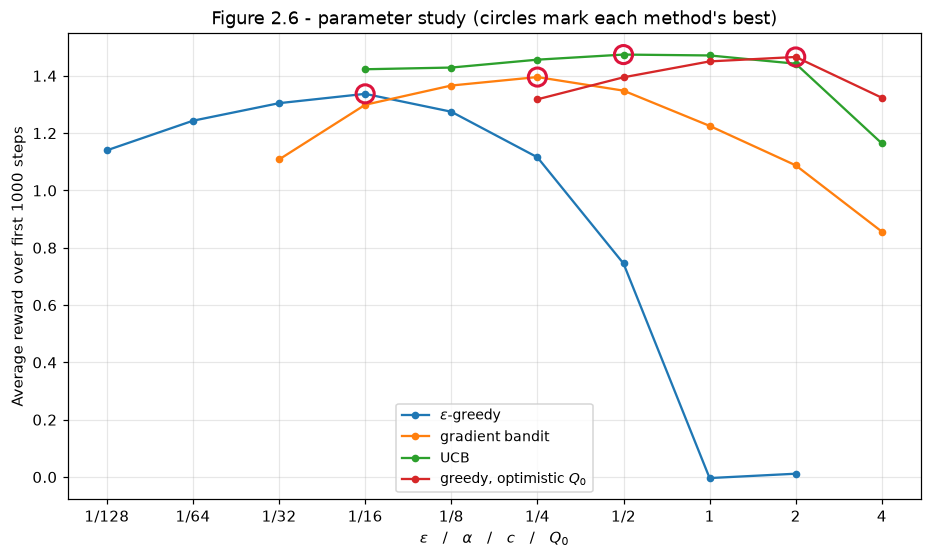

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, (xs, ys) in study.items():
    ax.plot(xs, ys, "o-", ms=4, label=name)
    i = int(np.argmax(ys))
    ax.scatter([xs[i]], [ys[i]], s=140, facecolors="none", edgecolors="crimson", lw=2,
               zorder=5)
ax.set_xticks(powers); ax.set_xticklabels(labels_x)
ax.set_xlabel(r"$\varepsilon$   /   $\alpha$   /   $c$   /   $Q_0$")
ax.set_ylabel(f"Average reward over first {STUDY_STEPS} steps")
ax.set_title("Figure 2.6 - parameter study (circles mark each method's best)")
ax.legend(loc="lower center", fontsize=9); ax.grid(alpha=0.3)
plt.show()

In [5]:
hide('''<b>Ranking (tuned, ~1.49 / 1.45 / 1.40 / 1.35):</b> UCB, then
greedy-with-optimistic-initialisation, then the gradient bandit, then &epsilon;-greedy.
The gaps at the peaks are real but modest &mdash; the book&#39;s own conclusion is that
<i>all of these methods are pretty good and none dominates</i>.
<br><br><b>Flattest:</b> compare the printed spreads. &epsilon;-greedy has by far the
largest (it collapses badly on the high-&epsilon; side, because you pay &epsilon; forever);
UCB and the gradient bandit are broad and forgiving across their middle ranges; optimistic
Q_0 is flattest of all over the range plotted, though that range is narrower by
construction &mdash; too small a Q_0 gives no exploratory sweep at all.
<br><br><b>The caveat that matters:</b> every number here is
&quot;average reward over the first 1000 steps&quot;. Change the horizon and the ranking
moves &mdash; which is exactly what the next cell shows. No single parameter study settles
the question.''')

## The comparison the parameter study hides: horizon

Figure 2.6 fixes the horizon at 1000 steps. That is a *choice*, and it changes the answer.

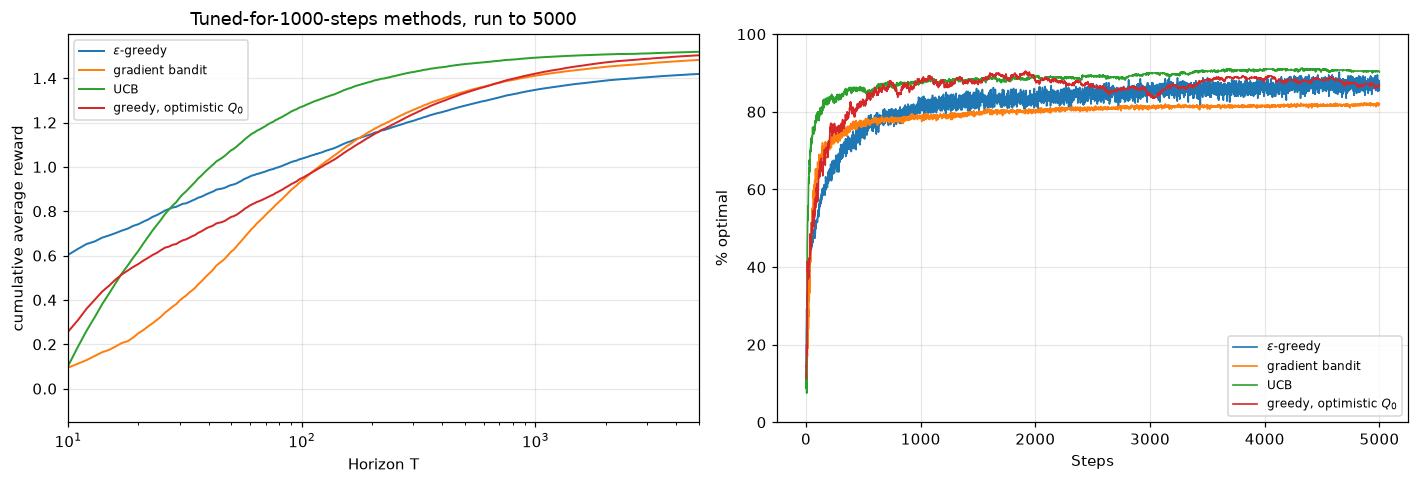

$\varepsilon$-greedy       T=100: 1.035  T=500: 1.276  T=1000: 1.347  T=5000: 1.419
gradient bandit            T=100: 0.933  T=500: 1.340  T=1000: 1.411  T=5000: 1.482
UCB                        T=100: 1.270  T=500: 1.463  T=1000: 1.492  T=5000: 1.519
greedy, optimistic $Q_0$   T=100: 0.947  T=500: 1.333  T=1000: 1.420  T=5000: 1.503


In [6]:
best_params = {name: 2.0 ** xs[int(np.argmax(ys))] for name, (xs, ys) in study.items()}
makers = {n: methods[n][0] for n in methods}

T = 5000
curves = {}
for name, p in best_params.items():
    curves[name] = run_bandit(makers[name](p), steps=T, runs=400, seed=77)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, r in curves.items():
    axes[0].plot(np.cumsum(r["rewards"]) / np.arange(1, T + 1), label=name, lw=1.3)
    axes[1].plot(r["optimal"], label=name, lw=1.1)
axes[0].set_xscale("log"); axes[0].set_xlim(10, T)
axes[0].set_xlabel("Horizon T"); axes[0].set_ylabel("cumulative average reward")
axes[0].set_title("Tuned-for-1000-steps methods, run to 5000")
axes[1].set_xlabel("Steps"); axes[1].set_ylabel("% optimal"); axes[1].set_ylim(0, 100)
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for name, r in curves.items():
    line = "  ".join(f"T={T_}: {r['rewards'][:T_].mean():.3f}"
                     for T_ in [100, 500, 1000, 5000])
    print(f"{name:<26} {line}")

## Regret, the theorist's view

Same experiment, scored by cumulative regret. This is where the asymptotic character of
each method becomes unmistakable: a straight line on a linear plot means constant-rate
mistakes forever; curvature toward flat means the method is genuinely converging.

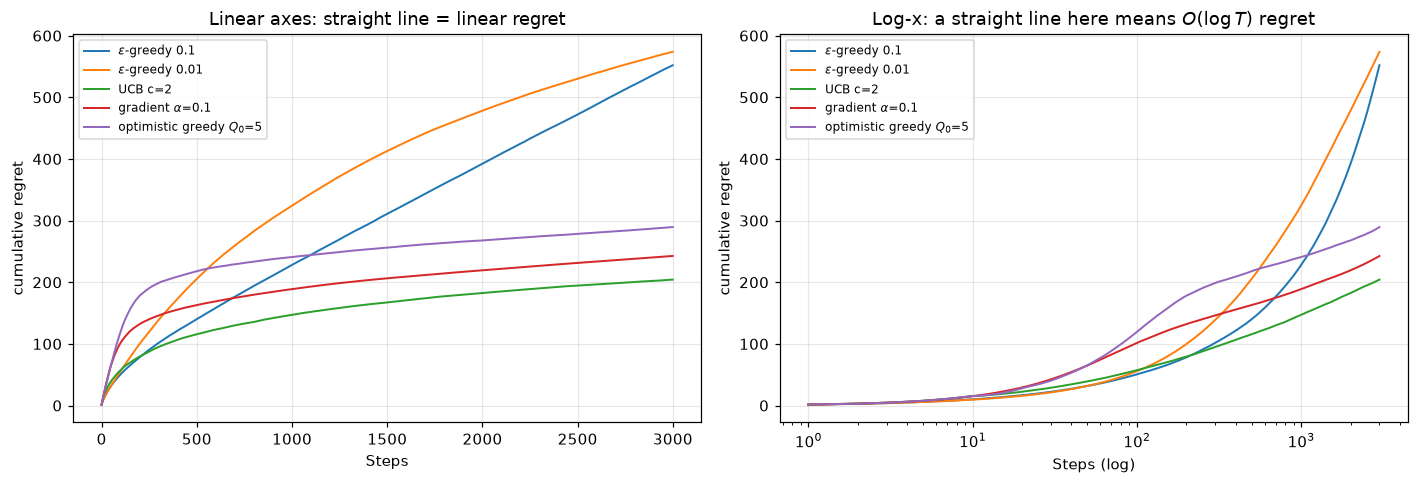

In [7]:
def regret_curve(agent_fn, steps=3000, runs=400, seed=0):
    tb = Testbed(runs=runs, seed=seed)
    rng = np.random.default_rng(seed + 5)
    agent = agent_fn(tb.k, runs, rng)
    best_val = tb.q_star.max(axis=1)
    reg = np.zeros(steps)
    idx = np.arange(runs)
    for t in range(steps):
        a = agent.act()
        inst = best_val - tb.q_star[idx, a]
        r = tb.step(a)
        agent.update(a, r)
        reg[t] = inst.mean()
    return np.cumsum(reg)

T = 3000
regrets = {
    "$\\varepsilon$-greedy 0.1": eps_agent(0.1),
    "$\\varepsilon$-greedy 0.01": eps_agent(0.01),
    "UCB c=2": ucb_agent(2.0),
    "gradient $\\alpha$=0.1": grad_agent(0.1),
    "optimistic greedy $Q_0$=5": eps_agent(0.0, Q_init=5.0, alpha=0.1),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, ag in regrets.items():
    R = regret_curve(ag, steps=T, seed=9)
    axes[0].plot(R, label=name, lw=1.3)
    axes[1].semilogx(np.arange(1, T + 1), R, label=name, lw=1.3)
axes[0].set_xlabel("Steps"); axes[0].set_ylabel("cumulative regret")
axes[0].set_title("Linear axes: straight line = linear regret")
axes[1].set_xlabel("Steps (log)"); axes[1].set_ylabel("cumulative regret")
axes[1].set_title("Log-x: a straight line here means $O(\\log T)$ regret")
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

On the log-x panel, UCB is close to a straight line — that is $O(\log T)$ regret, visible
with your eyes. $\varepsilon$-greedy with fixed $\varepsilon = 0.1$ curves upward on log-x,
i.e. it is linear in $T$: it keeps paying $\approx \varepsilon \cdot \overline{\Delta}$ per
step forever. $\varepsilon = 0.01$ is linear too, just with a gentler slope — and it looked
*worse* than $0.1$ in Figure 2.2 only because 1000 steps is short.

**This is why "average reward at step 1000" and "regret growth rate" can rank methods
differently, and why you should always know which one you care about.**

## The chapter on one page

| Method | Exploration driven by | Ceiling on % optimal | Nonstationary? | Extends to full RL? |
|---|---|---|---|---|
| greedy | nothing | ~35% (structural) | no | trivially |
| $\varepsilon$-greedy | randomness | $1-\varepsilon+\varepsilon/k$ | yes, with constant $\alpha$ | yes, ubiquitous |
| optimistic init | initial bias | ~100% | **no** (one-shot) | partially |
| UCB | uncertainty ($\ln t / N$) | ~100% | poorly | hard (needs counts) |
| gradient bandit | soft-max stochasticity | ~100% | yes, with constant baseline | yes → policy gradients |

And the ideas that survive into every later chapter:

1. **NewEstimate ← OldEstimate + StepSize [Target − OldEstimate]** (2.4)
2. **Step size = memory length**; constant $\alpha$ for nonstationary targets (2.5)
3. **Optimism in the face of uncertainty** (2.6, 2.7)
4. **Baselines reduce variance for free** (2.8) → advantage functions, actor-critic
5. **Exploration must be sustained**, because the environment (or your policy) changes

## What Chapter 2 deliberately leaves out

- **Thompson sampling / posterior sampling** — maintain a posterior over each $q_*(a)$,
  sample from it, act greedily on the sample. Usually beats UCB in practice and is barely
  more code. The book mentions Bayesian methods in 2.9 but does not develop them.
- **Gittins indices** — the exact optimal solution to the Bayesian bandit problem with
  discounting. Beautiful, and does not generalise to full RL, which is why it is a
  footnote.
- **Full Bayesian planning across steps** — computationally hopeless beyond a horizon of
  a few, but it is the *right* formulation of the exploration-exploitation trade-off, and
  Chapter 2 closes by noting that approximating it is a live research direction.

## A parting exercise

Implement Thompson sampling for the Gaussian testbed (posterior over $q_*(a)$ is Normal
with known noise variance 1, so with a $\mathcal{N}(0,1)$ prior the posterior after $n$
pulls with mean $\hat\mu$ is $\mathcal{N}\!\left(\frac{n\hat\mu}{n+1}, \frac{1}{n+1}\right)$),
add it to the parameter study above, and see where it lands. The starter is below.

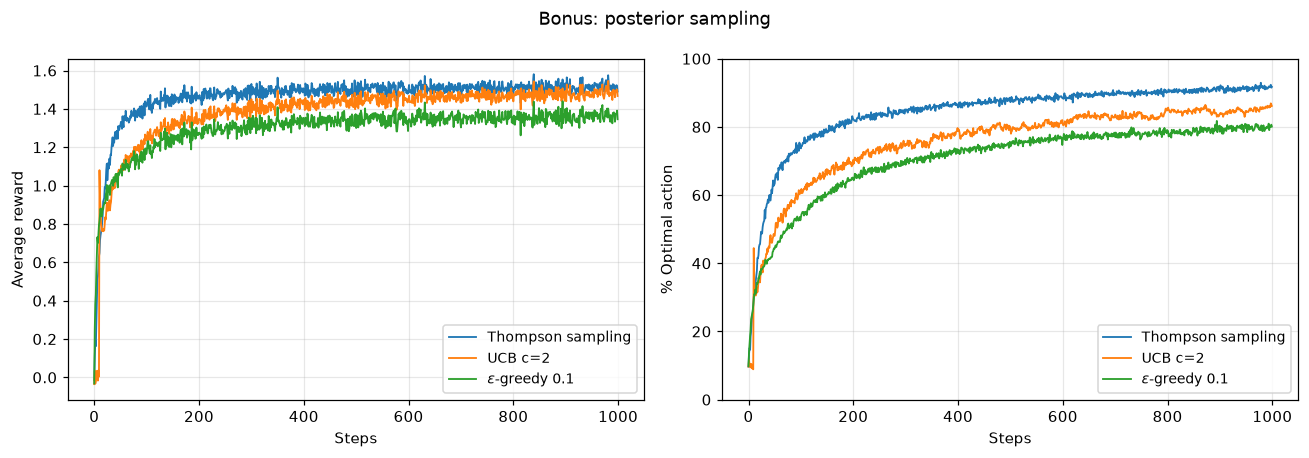

Thompson     avg reward = 1.462  %opt last 100 = 91.3
UCB          avg reward = 1.383  %opt last 100 = 84.9
eps-greedy   avg reward = 1.297  %opt last 100 = 79.7


In [8]:
class ThompsonGaussian:
    def __init__(self, k, runs, rng, prior_var=1.0, scale=1.0):
        self.k, self.runs, self.rng = k, runs, rng
        self.scale = scale
        self.mu = np.zeros((runs, k)); self.n = np.zeros((runs, k))
        self.sum = np.zeros((runs, k)); self.prior_var = prior_var

    def act(self):
        post_var = 1.0 / (self.n + 1.0 / self.prior_var)
        post_mean = self.sum * post_var
        sample = self.rng.normal(post_mean, self.scale * np.sqrt(post_var))
        return sample.argmax(axis=1)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.n[idx, a] += 1
        self.sum[idx, a] += r


ts = run_bandit(lambda k, runs, rng: ThompsonGaussian(k, runs, rng), seed=31)
ucb = run_bandit(ucb_agent(2.0), seed=31)
eg = run_bandit(eps_agent(0.1), seed=31)

plot_pair([ts, ucb, eg],
          ["Thompson sampling", "UCB c=2", "$\\varepsilon$-greedy 0.1"],
          title="Bonus: posterior sampling")
plt.show()

for lab, r in [("Thompson", ts), ("UCB", ucb), ("eps-greedy", eg)]:
    print(f"{lab:<12} avg reward = {r['rewards'].mean():.3f}  "
          f"%opt last 100 = {r['optimal'][-100:].mean():.1f}")

Things to try from here, roughly in order of how much they will teach you:

1. **Decaying $\varepsilon$** ($\varepsilon_t = \min(1, c/t)$ or $c/\sqrt{t}$) — does it
   get $O(\log T)$ regret? Add it to the regret plot.
2. **Sliding-window UCB** — replace $N_t(a)$ with a count over the last $W$ steps and
   rerun the nonstationary experiment from 2.5.
3. **Sweep the number of arms $k$** — which methods degrade fastest as $k$ grows to 100?
4. **Adversarial rewards** — break every method here by making $q_*$ change in response
   to what you pick. This is the honest preview of why full RL is hard.